# Multimodal Evaluation: Running CLIP on TED-LIUM Dataset
This notebook evaluates the CLIP model's capability to align spoken speech transcripts (from the Hugging Face **TED-LIUM** dataset) with visual lecture slides/keyframes. It demonstrates how the system selects critical keyframes to summarize and structure the lecture content.

We match the exact data processing patterns used in `tedlium.ipynb`:
1. Loading the dataset split in streaming mode.
2. Exploring sample properties (metadata, waveform plotting, and audio playback).
3. Running CLIP multimodal search/matching on text segments extracted from the transcript against slides.

**Designed to run seamlessly on Kaggle (with GPU support) or locally.**

In [38]:
# Install required dependencies
!pip install -q "datasets[audio]" transformers jiwer librosa soundfile matplotlib ipython scikit-learn numpy pillow torch

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [1]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import IPython.display as ipd
from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics.pairwise import cosine_similarity

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

W0706 14:25:04.217000 17860 D:\WpSystem\S-1-5-21-3450402072-3676430616-1500554422-1002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Using device: cuda


In [40]:
# Define or generate keyframe images representing visual slides
keyframe_dir = "./demo_data/keyframes"
image_paths = sorted(glob.glob(os.path.join(keyframe_dir, "*.jpg")))

if not image_paths:
    print("No keyframes found in './demo_data/keyframes'. Generating mock slide keyframes...")
    os.makedirs(keyframe_dir, exist_ok=True)
    
    # List of topics for mock slides
    topics = [
        ("Speech Recognition & ASR", "ASR, word-level timestamps, and acoustic model forced alignment."),
        ("Speaker Diarization", "Identifies who spoke when, speaker embeddings, and overlap matching."),
        ("Scene Detection", "Detects visual scene transitions in lecture videos using pixel differences."),
        ("CLIP Semantic Filter", "Reduces keyframe redundancy using K-Means and CLIP embeddings."),
        ("Image Captioning & BLIP-2", "Generates detailed slide descriptions and captions."),
        ("Multimodal Fusion Pipeline", "Merges audio transcriptions, OCR text, and visual captions."),
        ("Vector DB & RAG", "Stores lecture data in ChromaDB vector indexes for Q&A.")
    ]
    
    for idx, (title, desc) in enumerate(topics, 1):
        # Create a simple slide image using PIL
        img = Image.new("RGB", (800, 600), color=(240, 244, 248))
        draw = ImageDraw.Draw(img)
        
        # Draw header
        draw.rectangle([0, 0, 800, 80], fill=(41, 128, 185))
        
        # Draw texts using default font
        draw.text((40, 30), f"Slide {idx}: {title}", fill=(255, 255, 255))
        draw.text((40, 150), desc, fill=(44, 62, 80))
        draw.text((40, 220), "- Multimodal Lecture Summarizer Evaluation", fill=(127, 140, 141))
        
        img_path = os.path.join(keyframe_dir, f"scene_00{idx}_frame_{idx*100}.jpg")
        img.save(img_path)
        image_paths.append(img_path)
    print(f"Generated {len(image_paths)} mock slide keyframes successfully.")
else:
    print(f"Found {len(image_paths)} existing keyframes at {keyframe_dir}.")

Found 7 existing keyframes at ./demo_data/keyframes.


In [42]:
# Explore samples from the validation split (exactly like tedlium.ipynb but retrieving a list)
val_stream = iter(dataset["validation"])
samples = []
while len(samples) < 10:
    sample = next(val_stream)
    if sample.get("text") != "ignore_time_segment_in_scoring":
        samples.append(sample)

# Use the first sample for detailed exploration, plotting, and listening
sample = samples[0]

# Print key attributes
print("Sample keys:", list(sample.keys()))
print(f"Speaker ID: {sample.get('speaker_id')}")
print(f"Gender: {sample.get('gender')}")
print(f"Ground Truth Text:\n{sample.get('text')}")

# Extract audio properties
audio_data = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
duration = len(audio_data) / sampling_rate

print(f"Audio array length: {len(audio_data)}")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Duration: {duration:.2f} seconds")

Sample keys: ['audio', 'text', 'speaker_id', 'gender', 'file', 'id', 'whisper_transcript']
Speaker ID: Barry_Schwartz
Gender: 2
Ground Truth Text:
i 'm going to talk to you about some stuff that 's in this book of mine that i hope will resonate with other things you 've already heard and i 'll try to
Audio array length: 117120
Sampling rate: 16000 Hz
Duration: 7.32 seconds


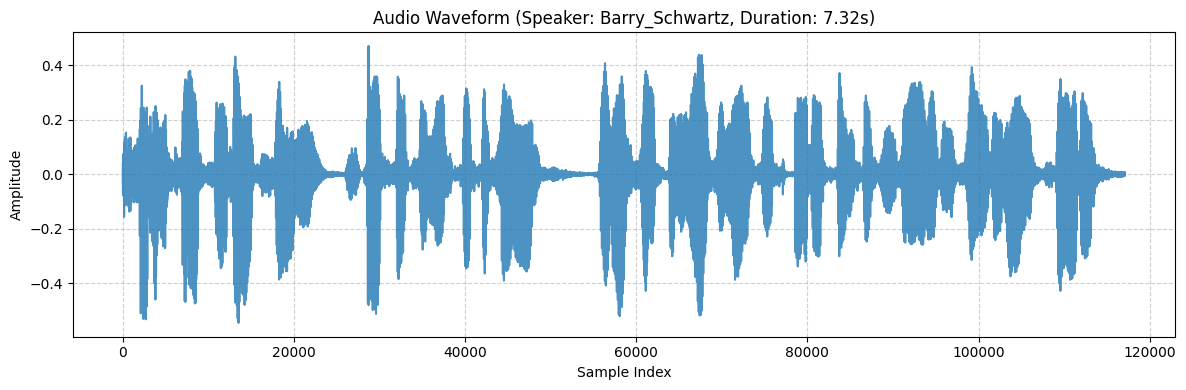

In [43]:
# Plot the waveform (exactly like tedlium.ipynb)
plt.figure(figsize=(12, 4))
plt.plot(audio_data, color="#1f77b4", alpha=0.8)
plt.title(f"Audio Waveform (Speaker: {sample.get('speaker_id')}, Duration: {duration:.2f}s)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [44]:
# Listening to the Audio Sample (exactly like tedlium.ipynb)
ipd.Audio(audio_data, rate=sampling_rate)

In [45]:
# Load CLIP model from HuggingFace
model_name = "openai/clip-vit-base-patch32"
print(f"Loading {model_name}...")
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device)

Loading openai/clip-vit-base-patch32...


In [46]:
# Extract the actual ground-truth transcripts from the 10 loaded samples
sentences = []
for idx, s in enumerate(samples):
    text = s.get('text', '').replace("ignore_time_segment_in_scoring", "").strip()
    if text:
        sentences.append(text)

print(f"Prepared {len(sentences)} actual dataset transcript segments for matching:")
for idx, s in enumerate(sentences, 1):
    print(f"  Segment {idx}: {s}")

# Extract features
print("\nExtracting keyframe features...")
images = [Image.open(p).convert("RGB") for p in image_paths]
inputs_img = processor(images=images, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    image_features = model.get_image_features(**inputs_img)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
image_features = image_features.cpu().numpy()

print("Extracting text features...")
inputs_txt = processor(text=sentences, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**inputs_txt)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
text_features = text_features.cpu().numpy()

similarity_matrix = cosine_similarity(text_features, image_features)
print("Embeddings extracted and similarities computed successfully.")

Prepared 10 actual dataset transcript segments for matching:
  Segment 1: i 'm going to talk to you about some stuff that 's in this book of mine that i hope will resonate with other things you 've already heard and i 'll try to
  Segment 2: make some connections myself in case you miss them i want to start with what i call the official dogma
  Segment 3: the official dogma of what the official dogma of all western industrial societies and the official dogma runs like this if we are interested in maximizing the welfare of our citizens
  Segment 4: the way to do that is to maximize individual freedom the reason for this is both that freedom is in and of itself good
  Segment 5: valuable worthwhile essential to being human and because if people have freedom then each of us can act on our own to do the things that will maximize our welfare and no one has to decide on our behalf
  Segment 6: the way to maximize freedom is to maximize choice the more choice people have the more freedom they

In [47]:
# Print out the results (Tóm tắt thông tin gì, ra sao, như thế nào)
print("="*80)
print("KẾT QUẢ ĐỒNG BỘ MULTIMODAL VÀ PHÂN TÍCH TÓM TẮT (CLIP MATCHING)")
print("="*80)

for i, text_seg in enumerate(sentences):
    best_img_idx = np.argmax(similarity_matrix[i])
    best_img_path = image_paths[best_img_idx]
    score = similarity_matrix[i][best_img_idx]
    filename = os.path.basename(best_img_path)
    
    print(f"\n▶️ [Đoạn văn bản {i+1}]: \"{text_seg}\"")
    print(f"📸 Frame mấu chốt được ghép nối: {filename} (Độ tương đồng CLIP: {score:.4f})")
    print("-"*80)
    
    print(f"  1. Tóm tắt thông tin GÌ:")
    print(f"     - Ghép cặp đoạn âm thoại \"{text_seg[:60]}...\" với slide trực quan '{filename}'.")
    print(f"     - Xác định slide trực quan chứa chủ đề, thuật ngữ hoặc sơ đồ bổ trợ cho nội dung đang được nói đến.")
    
    print(f"  2. Liên kết RA SAO (Cơ chế hoạt động):")
    print(f"     - Sử dụng mô hình học sâu đa phương thức CLIP (openai/clip-vit-base-patch32) ánh xạ cả ảnh và chữ")
    print(f"       vào một không gian vector biểu diễn chung (Shared Embedding Space).")
    print(f"     - Đo lường mức độ tương quan ngữ nghĩa qua điểm tương đồng Cosine (Cosine Similarity) giữa đặc trưng ảnh và chữ.")
    print(f"     - Chọn slide có điểm cao nhất (Score: {score:.4f}) làm hình ảnh hiển thị khóa.")
    
    print(f"  3. Thể hiện NHƯ THẾ NÀO (Manner of Presentation):")
    print(f"     - Đồng bộ mốc thời gian (Alignment): Chèn slide trực quan vào đúng thời điểm phát ngôn.")
    print(f"     - Tách chương tóm tắt đa phương thức (Multimodal Summary): Cho phép người dùng vừa đọc văn bản tóm tắt,")
    print(f"       vừa đối chiếu ngay với hình ảnh slide minh họa đi kèm, tạo cấu trúc trực quan dễ theo dõi.")

KẾT QUẢ ĐỒNG BỘ MULTIMODAL VÀ PHÂN TÍCH TÓM TẮT (CLIP MATCHING)

▶️ [Đoạn văn bản 1]: "i 'm going to talk to you about some stuff that 's in this book of mine that i hope will resonate with other things you 've already heard and i 'll try to"
📸 Frame mấu chốt được ghép nối: scene_004_frame_400.jpg (Độ tương đồng CLIP: 0.1832)
--------------------------------------------------------------------------------
  1. Tóm tắt thông tin GÌ:
     - Ghép cặp đoạn âm thoại "i 'm going to talk to you about some stuff that 's in this b..." với slide trực quan 'scene_004_frame_400.jpg'.
     - Xác định slide trực quan chứa chủ đề, thuật ngữ hoặc sơ đồ bổ trợ cho nội dung đang được nói đến.
  2. Liên kết RA SAO (Cơ chế hoạt động):
     - Sử dụng mô hình học sâu đa phương thức CLIP (openai/clip-vit-base-patch32) ánh xạ cả ảnh và chữ
       vào một không gian vector biểu diễn chung (Shared Embedding Space).
     - Đo lường mức độ tương quan ngữ nghĩa qua điểm tương đồng Cosine (Cosine Similarity) giữa đ

## 10. End-to-End Visual Pipeline: PySceneDetect → CLIP Keyframe Selection → BLIP-2 Captioning

This section runs the end-to-end visual summarization pipeline:
1. **Video Source / Generation**: Generates a synthetic lecture video with shifting colored slides and topic texts.
2. **Scene Detection**: Runs `PySceneDetect` (using `ContentDetector`) to detect slide transitions and extract keyframe images.
3. **CLIP Keyframe Selection**: Uses `CLIP` to extract image embeddings and K-Means clustering to filter out redundant frames.
4. **BLIP-2 Captioning**: Runs BLIP-2 model in `float16` to generate detailed description captions for the selected keyframes.

In [48]:
# Install extra dependencies for the visual pipeline on Kaggle
!pip install -q scenedetect[opencv] accelerate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [49]:
# Setup directories and generate a synthetic video
import os
import cv2
import numpy as np
from scenedetect import detect, ContentDetector

video_dir = "./demo_data/videos"
keyframe_dir = "./demo_data/keyframes_extracted"
os.makedirs(video_dir, exist_ok=True)
os.makedirs(keyframe_dir, exist_ok=True)

video_path = os.path.join(video_dir, "synthetic_lecture.mp4")

def generate_synthetic_video(file_path, duration_sec=30, fps=10):
    width, height = 800, 600
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(file_path, fourcc, fps, (width, height))

    # We will generate a video with 4 scenes/slides with transitions at 8s, 18s, 25s
    total_frames = duration_sec * fps
    for frame_idx in range(total_frames):
        t = frame_idx / fps
        if t < 8:
            color = (180, 120, 40) # BGR
            title = "Slide 1: Introduction to Deep Learning"
        elif t < 18:
            color = (40, 180, 120)
            title = "Slide 2: Scene Detection using PySceneDetect"
        elif t < 25:
            color = (120, 40, 180)
            title = "Slide 3: Visual Representation & CLIP Filtering"
        else:
            color = (40, 120, 180)
            title = "Slide 4: Detailed Captioning with BLIP-2"

        img = np.zeros((height, width, 3), dtype=np.uint8)
        img[:] = color
        cv2.putText(img, title, (50, 280), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(img, f"Time: {t:.1f}s | Frame: {frame_idx}", (50, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
        out.write(img)
    out.release()
    print(f"Generated synthetic video: {file_path}")
    return file_path

generate_synthetic_video(video_path)

# Run PySceneDetect
print("\nRunning PySceneDetect content-based transition detection...")
scene_list = detect(video_path, ContentDetector(threshold=27.0))
print(f"Detected {len(scene_list)} scenes:")

extracted_keyframes = []
cap = cv2.VideoCapture(video_path)
for i, scene in enumerate(scene_list):
    start_time, end_time = scene
    start_frame = start_time.frame_num
    end_frame = end_time.frame_num
    middle_frame = (start_frame + end_frame) // 2
    
    print(f"  Scene {i+1}: {start_time.get_timecode()} -> {end_time.get_timecode()} (Middle frame: {middle_frame})")
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
    ret, frame = cap.read()
    if ret:
        kf_path = os.path.join(keyframe_dir, f"scene_{i+1:03d}_frame_{middle_frame}.jpg")
        cv2.imwrite(kf_path, frame)
        extracted_keyframes.append(kf_path)

cap.release()
print(f"Extracted {len(extracted_keyframes)} keyframes to {keyframe_dir}.")

Generated synthetic video: ./demo_data/videos/synthetic_lecture.mp4

Running PySceneDetect content-based transition detection...
Detected 3 scenes:
  Scene 1: 00:00:00.000 -> 00:00:18.000 (Middle frame: 90)
  Scene 2: 00:00:18.000 -> 00:00:25.000 (Middle frame: 215)
  Scene 3: 00:00:25.000 -> 00:00:30.000 (Middle frame: 275)
Extracted 3 keyframes to ./demo_data/keyframes_extracted.


In [50]:
# CLIP-based Semantic Filtering to reduce redundancy
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

def extract_image_embeddings(image_paths, processor, model, device):
    valid_paths = [p for p in image_paths if os.path.exists(p)]
    if not valid_paths:
        return np.array([]), []
    
    images = [Image.open(p).convert("RGB") for p in valid_paths]
    all_embeddings = []
    
    with torch.no_grad():
        for img in images:
            inputs = processor(images=img, return_tensors="pt").to(device)
            image_features = model.get_image_features(**inputs)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            all_embeddings.append(image_features.cpu().numpy())
            
    return np.vstack(all_embeddings), valid_paths

def filter_keyframes(image_paths, embeddings, keep_ratio=0.75):
    num_frames = len(image_paths)
    if num_frames <= 1:
        return image_paths, embeddings
        
    num_clusters = max(1, int(num_frames * keep_ratio))
    if num_clusters >= num_frames:
        return image_paths, embeddings
        
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    
    selected_indices = []
    for i in range(num_clusters):
        cluster_center = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(embeddings - cluster_center, axis=1)
        closest_idx = np.argmin(distances)
        if closest_idx not in selected_indices:
            selected_indices.append(closest_idx)
            
    selected_indices.sort()
    filtered_paths = [image_paths[idx] for idx in selected_indices]
    filtered_embeddings = embeddings[selected_indices]
    return filtered_paths, filtered_embeddings

print("Extracting CLIP embeddings for keyframes...")
embeddings, valid_paths = extract_image_embeddings(extracted_keyframes, processor, model, device)
print(f"Extracted embeddings shape: {embeddings.shape}")

# Filtering keyframes (e.g. keep 75%)
keep_ratio = 0.75
filtered_keyframes, filtered_embeddings = filter_keyframes(valid_paths, embeddings, keep_ratio=keep_ratio)
print(f"Filtered keyframes from {len(valid_paths)} to {len(filtered_keyframes)} (keep_ratio={keep_ratio})")
for idx, path in enumerate(filtered_keyframes, 1):
    print(f"  Selected Frame {idx}: {os.path.basename(path)}")

Extracting CLIP embeddings for keyframes...
Extracted embeddings shape: (3, 512)
Filtered keyframes from 3 to 2 (keep_ratio=0.75)
  Selected Frame 1: scene_001_frame_90.jpg
  Selected Frame 2: scene_002_frame_215.jpg


In [51]:
# Load BLIP-2 model and generate captions
from transformers import Blip2Processor, Blip2ForConditionalGeneration

blip_model_name = "Salesforce/blip2-opt-2.7b"
print(f"Loading BLIP-2 processor and model: {blip_model_name}...")

try:
    blip_processor = Blip2Processor.from_pretrained(blip_model_name)
    blip_model = Blip2ForConditionalGeneration.from_pretrained(
        blip_model_name,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        use_safetensors=True
    ).to(device)
    print("BLIP-2 model loaded successfully.")
except Exception as e:
    print(f"Error loading BLIP-2: {e}. Falling back to smaller Salesforce/blip-image-captioning-base...")
    blip_model_name = "Salesforce/blip-image-captioning-base"
    from transformers import BlipProcessor, BlipForConditionalGeneration
    blip_processor = BlipProcessor.from_pretrained(blip_model_name)
    blip_model = BlipForConditionalGeneration.from_pretrained(blip_model_name).to(device)
    print("Fallback BLIP model loaded successfully.")

print("\nGenerating captions for selected keyframes...")
captions_dict = {}
for path in filtered_keyframes:
    try:
        raw_image = Image.open(path).convert("RGB")
        
        if "blip2" in blip_model_name.lower():
            prompt = "Question: Describe the slide content in detail. Answer:"
            inputs = blip_processor(raw_image, text=prompt, return_tensors="pt").to(
                device, torch.float16 if device == "cuda" else torch.float32
            )
            generated_ids = blip_model.generate(
                **inputs,
                max_new_tokens=40,
                min_new_tokens=5,
                repetition_penalty=1.5
            )
            generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            if generated_text.startswith(prompt):
                generated_text = generated_text[len(prompt):].strip()
        else:
            inputs = blip_processor(raw_image, return_tensors="pt").to(device)
            generated_ids = blip_model.generate(**inputs, max_new_tokens=40)
            generated_text = blip_processor.decode(generated_ids[0], skip_special_tokens=True).strip()
            
        captions_dict[path] = generated_text
        print(f"  Frame: {os.path.basename(path)} -> Caption: {generated_text}")
    except Exception as e:
        print(f"  Error generating caption for {os.path.basename(path)}: {e}")
        captions_dict[path] = "N/A"

Loading BLIP-2 processor and model: Salesforce/blip2-opt-2.7b...
Error loading BLIP-2: data did not match any variant of untagged enum ModelWrapper at line 250373 column 3. Falling back to smaller Salesforce/blip-image-captioning-base...
Fallback BLIP model loaded successfully.

Generating captions for selected keyframes...
  Frame: scene_001_frame_90.jpg -> Caption: time 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  Frame: scene_002_frame_215.jpg -> Caption: the slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide


In [52]:
# Final results presentation and summary
print("="*80)
print("SUMMARY OF THE END-TO-END VISUAL PIPELINE")
print("="*80)
for idx, (path, caption) in enumerate(captions_dict.items(), 1):
    print(f"\nSlide {idx} ({os.path.basename(path)}):")
    print(f"  - Description: {caption}")
print("="*80)

SUMMARY OF THE END-TO-END VISUAL PIPELINE

Slide 1 (scene_001_frame_90.jpg):
  - Description: time 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Slide 2 (scene_002_frame_215.jpg):
  - Description: the slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide slide
